In [1]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
import numpy as np
from fairchem.core.datasets import AseDBDataset
import torch
from torch.nn import Linear
from torch_geometric.nn import SchNet
from torch_geometric.data import Data
from torch_cluster import radius_graph
import matplotlib.pyplot as plt
from read_multi_ase import *
from extract import *

W0422 10:47:52.662000 20197 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
dataset_path = "./train_4M/data0000.aselmdb"
dataset = AseDBDataset({"src": dataset_path})

In [3]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules= 200)
bio_data = get_data(bio_sample)
bio_train, bio_val = split_data(bio_data, 0.8)

Processed 200 atoms


In [4]:
bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)

In [5]:
class SchNetModel(torch.nn.Module):
    def __init__(self,
                 hidden_channels: int = 128,
                 num_filters: int = 128,
                 num_interactions: int = 6,
                 num_gaussians: int = 50,
                 cutoff: int = 10,
                 max_num_neighbors: int = 32,
                 readout: str = "mean"):
        super().__init__()

        #Create SchNet module with parameters
        self.schnet = SchNet(
            hidden_channels = hidden_channels,
            num_filters = num_filters,
            num_interactions = num_interactions,
            num_gaussians = num_gaussians,
            cutoff = cutoff,
            max_num_neighbors = max_num_neighbors,
            readout = readout
        )

    #Forward step for model
    def forward(self, data):
        out = self.schnet(data.z, data.pos, batch=data.batch)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bio_model = SchNetModel().to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=1e-4)
loss_fn = torch.nn.SmoothL1Loss()

def train(model: SchNetModel, train_data: list):
    model.train()
    total_loss = 0

    for data in train_data:
        data = data.to(device)

        optimizer.zero_grad()
        pred = model(data)
        loss = loss_fn(pred, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_data)

@torch.no_grad()
def evaluate(model: SchNetModel, val_data: list):
    model.eval()
    total_loss = 0

    for data in val_data:
        data = data.to(device)
        pred = model(data)

        loss = loss_fn(pred, data.y)
        total_loss += loss.item()

    return total_loss / len(val_data)

@torch.no_grad()
def test(model: SchNetModel, test_data: list):
    model.eval()

    total_mae = 0
    total_mse = 0
    total_samples = 0

    for data in test_data:
        data = data.to(device)

        pred = model(data)
        target = data.y.view(-1, 1)

        mae = torch.abs(pred - target).sum()
        mse = ((pred - target) ** 2).sum()

        total_mae += mae.item()
        total_mse += mse.item()
        total_samples += target.size(0)

    mean_mae = total_mae / total_samples
    rmse = (total_mse / total_samples) ** 0.5

    return mean_mae, rmse

In [6]:
epochs = 100
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:1052: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


Epoch 001 | Train Loss: 7.7498 | Val Loss: 6.8372
Epoch 006 | Train Loss: 2.0402 | Val Loss: 1.8591
Epoch 011 | Train Loss: 1.5189 | Val Loss: 1.6123
Epoch 016 | Train Loss: 1.3466 | Val Loss: 1.4764
Epoch 021 | Train Loss: 1.2323 | Val Loss: 1.4248
Epoch 026 | Train Loss: 1.1618 | Val Loss: 1.4170
Epoch 031 | Train Loss: 1.1389 | Val Loss: 1.4171
Epoch 036 | Train Loss: 1.1243 | Val Loss: 1.4033
Epoch 041 | Train Loss: 1.1312 | Val Loss: 1.4297
Epoch 046 | Train Loss: 1.0765 | Val Loss: 1.3983
Epoch 051 | Train Loss: 1.0733 | Val Loss: 1.3649
Epoch 056 | Train Loss: 1.1209 | Val Loss: 1.3997
Epoch 061 | Train Loss: 1.0723 | Val Loss: 1.3691
Epoch 066 | Train Loss: 1.0762 | Val Loss: 1.3552
Epoch 071 | Train Loss: 1.0676 | Val Loss: 1.3577
Epoch 076 | Train Loss: 1.0773 | Val Loss: 1.3659
Epoch 081 | Train Loss: 1.0655 | Val Loss: 1.3593
Epoch 086 | Train Loss: 1.0671 | Val Loss: 1.3746
Epoch 091 | Train Loss: 1.0683 | Val Loss: 1.3542
Epoch 096 | Train Loss: 1.0645 | Val Loss: 1.3674


In [7]:
def plot_losses(train_loss, val_loss):
    """Plot training vs validation loss from a history dict."""
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss',
             linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('SchNet Model Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

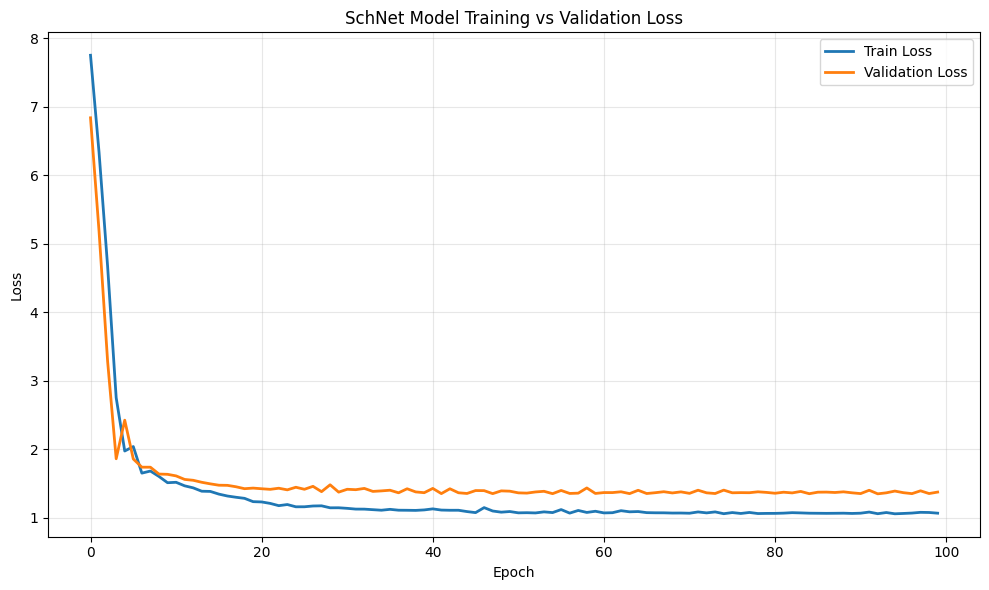

In [8]:
plot_losses(bio_train_losses, bio_val_losses)

In [9]:
bio_testing = process_file(file="./train_4M/data0001.aselmdb", molecule_type= "biomolecules", max_molecules= 200)
bio_test_data = get_data(bio_testing)

bio_test_loader = DataLoader(bio_test_data, batch_size=32)

mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Processed 200 atoms
Test MAE:  1.3431
Test RMSE: 1.8181
